Dataset Shape: (11537, 15)


C:\Users\ELCOT\AppData\Local\Temp\ipykernel_10912\2923198108.py:33: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


CV accuracy (5-fold): 0.3816 ± 0.0067
Best params: {'n_estimators': 200, 'min_samples_leaf': 3, 'max_features': 'log2', 'max_depth': 10}
Best CV score: 0.3801
Accuracy: 0.39312536106296936

Classification Report:
               precision    recall  f1-score   support

           0       0.10      0.10      0.10       100
           1       0.32      0.44      0.37       718
           2       0.37      0.24      0.29       936
           3       0.40      0.27      0.32       769
           4       0.48      0.64      0.55       939

    accuracy                           0.39      3462
   macro avg       0.33      0.34      0.33      3462
weighted avg       0.39      0.39      0.38      3462



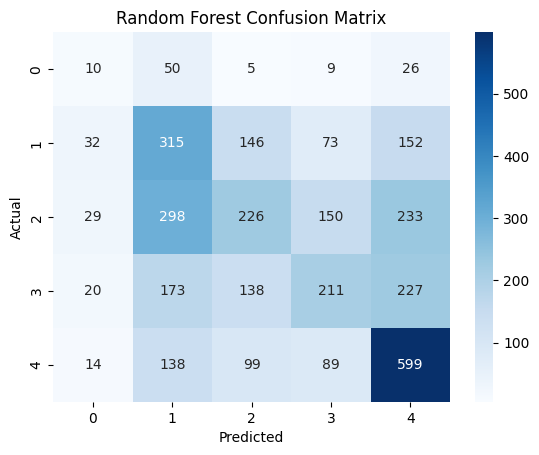

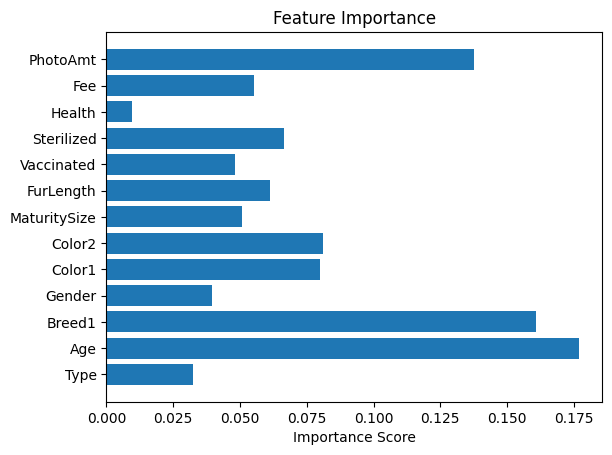

['rf_model.joblib']

In [9]:
# =========================
# PROGRAM 1: RANDOM FOREST
# =========================

# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# Step 3: Load dataset
file_name = "petfinder-mini.csv"  # automatically takes uploaded file
df = pd.read_csv(file_name)

print("Dataset Shape:", df.shape)

# Step 4: Preprocessing
# Remove unnecessary text columns
df = df.drop(columns=['Name','PetID','Description'], errors='ignore')

# Fill missing values
df.fillna(0, inplace=True)

# Convert categorical columns to numeric
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# Step 5: Define Features and Target
X = df.drop("AdoptionSpeed", axis=1)
y = df["AdoptionSpeed"]

# Step 6: Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Step 7: Train Model
# Use class weights to counter class imbalance and increase trees for stability
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    max_depth=15,
    min_samples_leaf=5
)

# Optional: quick cross-validation to sanity-check generalization
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy', n_jobs=-1)
print("CV accuracy (5-fold):", np.mean(cv_scores).round(4), "±", np.std(cv_scores).round(4))

# Hyperparameter tuning using RandomizedSearchCV
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_leaf': [1, 3, 5, 10],
    'max_features': ['sqrt', 'log2', 0.5, 0.75]
}

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=20,
    scoring='accuracy',
    cv=StratifiedKFold(n_splits=4, shuffle=True, random_state=42),
    n_jobs=-1,
    random_state=42,
    verbose=0
)

search.fit(X_train, y_train)
print("Best params:", search.best_params_)
print("Best CV score:", round(search.best_score_, 4))

best_rf = search.best_estimator_

# Step 8: Prediction
y_pred = best_rf.predict(X_test)

# Step 9: Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Step 10: Visualization - Confusion Matrix
plt.figure()
sns.heatmap(confusion_matrix(y_test,y_pred),
            annot=True,
            fmt="d",
            cmap="Blues")

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
# Step 11: Feature Importance
# Use the tuned estimator from RandomizedSearchCV
importances = best_rf.feature_importances_

plt.figure()
plt.barh(X.columns, importances)
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.show()

# Save the best-trained model for later use (e.g., prediction UI)
joblib.dump(best_rf, "rf_model.joblib")

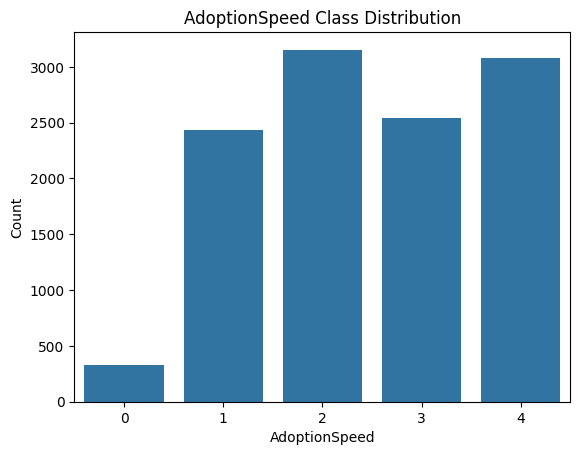

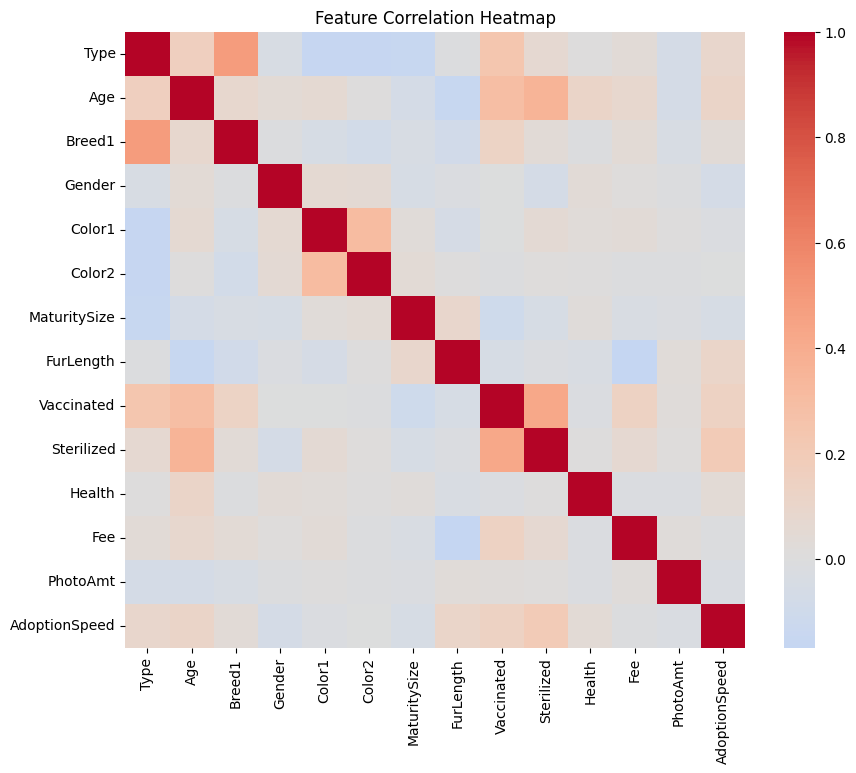

In [10]:
# Step 12: Additional Visualizations

# 12a: Class distribution
plt.figure()
sns.countplot(x=y)
plt.title("AdoptionSpeed Class Distribution")
plt.xlabel("AdoptionSpeed")
plt.ylabel("Count")
plt.show()

# 12b: Feature correlation heatmap
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()
